# ThessLink RL — Training Notebook

Εκπαίδευση και αξιολόγηση των αλγορίθμων **Q-Learning**, **DQN**, **PPO** σε grids 8×8, 32×32, 64×64.

**Action space:** `MultiDiscrete([5, 5])` — movement only, no explicit target selection. The reward function guides agents toward the cost-optimal POI.

| Grid | Q-Learning | DQN | PPO |
|------|-----------|-----|-----|
| 8×8  | `nav_qtable_8.pkl` | `nav_dqn_8.zip` | `nav_ppo_8.zip` |
| 32×32 | `nav_qtable_32.pkl` | `nav_dqn_32.zip` | `nav_ppo_32.zip` |
| 64×64 | `nav_qtable_64.pkl` | `nav_dqn_64.zip` | `nav_ppo_64.zip` |

In [10]:
import sys
from pathlib import Path

# Make sure the project root and lb-foraging are on the path
ROOT = Path(".").resolve()
LBF = ROOT / "lb-foraging"
for p in [str(ROOT), str(LBF)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print("Project root:", ROOT)

Project root: /home/stanimeros/Projects/thesslink-rl


In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from navigation_train import (
    train_ppo, train_dqn, train_qlearning,
    _eval_navigation, _discretize_nav, _NAV_ACTIONS,
    MODEL_DIR, get_history_path,
)

print("Imports OK")

Imports OK


---
## Βοηθητικές συναρτήσεις

In [12]:
import pickle

GRID_SIZES = [8]
ALGOS = ["ppo", "dqn", "qlearning"]


def cumulative_avg(values):
    return np.cumsum(values) / np.arange(1, len(values) + 1)


def get_plot_path(algo: str, grid_size: int | str):
    """Path to training_plot_*.png in the model folder."""
    return MODEL_DIR / algo / f"training_plot_{algo}_{str(grid_size)}.png"


def model_exists(algo: str, grid_size: int) -> bool:
    """Check if a trained model file exists."""
    tag = str(grid_size)
    if algo == "ppo":
        return (MODEL_DIR / "ppo" / f"nav_ppo_{tag}.zip").exists()
    elif algo == "dqn":
        return (MODEL_DIR / "dqn" / f"nav_dqn_{tag}.zip").exists()
    else:
        return (MODEL_DIR / "qlearning" / f"nav_qtable_{tag}.pkl").exists()


def history_exists(algo: str, grid_size: int) -> bool:
    """Check if training_history_*.pkl exists (source for plot generation)."""
    return get_history_path(algo, grid_size).exists()


def show_status():
    """Print a table showing which models and plots exist."""
    header = f"{'':12}" + "".join(f"{g:>8}" for g in GRID_SIZES)
    print(header)
    print("-" * (12 + 8 * len(GRID_SIZES)))
    for algo in ALGOS:
        row = f"{algo:<12}"
        for g in GRID_SIZES:
            m = "M" if model_exists(algo, g) else "."
            p = "H" if history_exists(algo, g) else "."
            row += f"  [{m}{p}]  "
        print(row)
    print("\nM=model exists  H=history (.pkl) exists  .=missing")


show_status()

                   8
--------------------
ppo           [MH]  
dqn           [MH]  
qlearning     [MH]  

M=model exists  H=history (.pkl) exists  .=missing


---
## Training

**Focus: 8×8 first** — optimize & validate before scaling to 64×64.

**Centralized controller:** A single model sees the full global state (35 floats: relative vectors to POIs + wall bits + cost components × 3 POIs) and outputs a **joint movement** `MultiDiscrete([5, 5])` (or `Discrete(25)` for DQN/Q-Learning). No explicit target selection — the reward function guides agents toward the cost-optimal POI via progress reward + cost-scaled terminal bonus. Agreement = arrived at cost-optimal POI.

Επίλεξε αλγόριθμο και grid size και τρέξε το αντίστοιχο cell.

### PPO

In [4]:
# 6 parallel envs (SubprocVecEnv), entropy bonus, 128x128 network
_PPO_STEPS = {8: 500_000, 32: 500_000, 64: 500_000}

GRID = 8   # ← αλλαγή: 8, 32, ή 64
STEPS = _PPO_STEPS[GRID]

train_ppo(
    total_timesteps=STEPS,
    seed=42,
    eval_freq=25_000,
    grid_size=(GRID, GRID),
)
show_status()

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 4830 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 768  |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 3903        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 1536        |
| train/                  |             |
|    approx_kl            | 0.011890043 |
|    clip_fraction        | 0.0813      |
|    clip_range           | 0.2         |
|    clip_range_vf        | 10          |
|    entropy_loss         | -3.21       |
|    explained_variance   | 0.0205      |
|    learning_rate        | 0.0003      |
|    loss                 | 1.07        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0143     |
|    value_loss           | 2.07        |
-----------------

### DQN

In [5]:
# 6 parallel envs, 128x128 network, buffer=200k
_DQN_STEPS = {8: 500_000, 32: 500_000, 64: 500_000}

GRID = 8   # ← αλλαγή: 8, 32, ή 64
STEPS = _DQN_STEPS[GRID]

train_dqn(
    total_timesteps=STEPS,
    seed=42,
    eval_freq=25_000,
    grid_size=(GRID, GRID),
)
show_status()

Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.991    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 19650    |
|    time_elapsed     | 0        |
|    total_timesteps  | 1800     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.991    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 19509    |
|    time_elapsed     | 0        |
|    total_timesteps  | 1806     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.983    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 19581    |
|    time_elapsed     | 0        |
|    total_timesteps  | 3498     |
----------------------------------
----------------------------------
| r

### Q-Learning

In [6]:
# Compact state (442,368 states) — parallel workers ~6x faster than single-threaded
EPISODES = 200_000
GRID = 8

train_qlearning(
    total_episodes=EPISODES,
    seed=42,
    eval_freq=10_000,   # 20 checkpoints over 200k episodes
    n_workers=6,        # parallel processes; each chunk split across workers
    grid_size=(GRID, GRID),
)
show_status()

Training Q-Learning (8×8) — 200,000 episodes in 20 chunks × 6 workers...
  Episode    10000: reward=-0.833  agreement=24.0%  ε=0.9512
  Episode    20000: reward=1.167  agreement=36.0%  ε=0.9049
  Episode    30000: reward=1.175  agreement=35.0%  ε=0.8608
  Episode    40000: reward=0.446  agreement=33.0%  ε=0.8188
  Episode    50000: reward=2.402  agreement=43.0%  ε=0.7789
  Episode    60000: reward=1.806  agreement=42.0%  ε=0.7409
  Episode    70000: reward=2.420  agreement=44.0%  ε=0.7048
  Episode    80000: reward=2.117  agreement=43.0%  ε=0.6704
  Episode    90000: reward=1.527  agreement=40.0%  ε=0.6377
  Episode   100000: reward=0.177  agreement=31.0%  ε=0.6066
  Episode   110000: reward=0.623  agreement=33.0%  ε=0.5771
  Episode   120000: reward=-0.263  agreement=28.0%  ε=0.5489
  Episode   130000: reward=-0.873  agreement=23.0%  ε=0.5222
  Episode   140000: reward=0.633  agreement=33.0%  ε=0.4967
  Episode   150000: reward=0.182  agreement=30.0%  ε=0.4725
  Episode   160000: rewa

### Σύγκριση PPO, DQN, Q-Learning (combined)

Όλα τα τρία μοντέλα σε ένα figure. Απαιτεί `training_history_*.pkl` από προηγούμενα training runs.

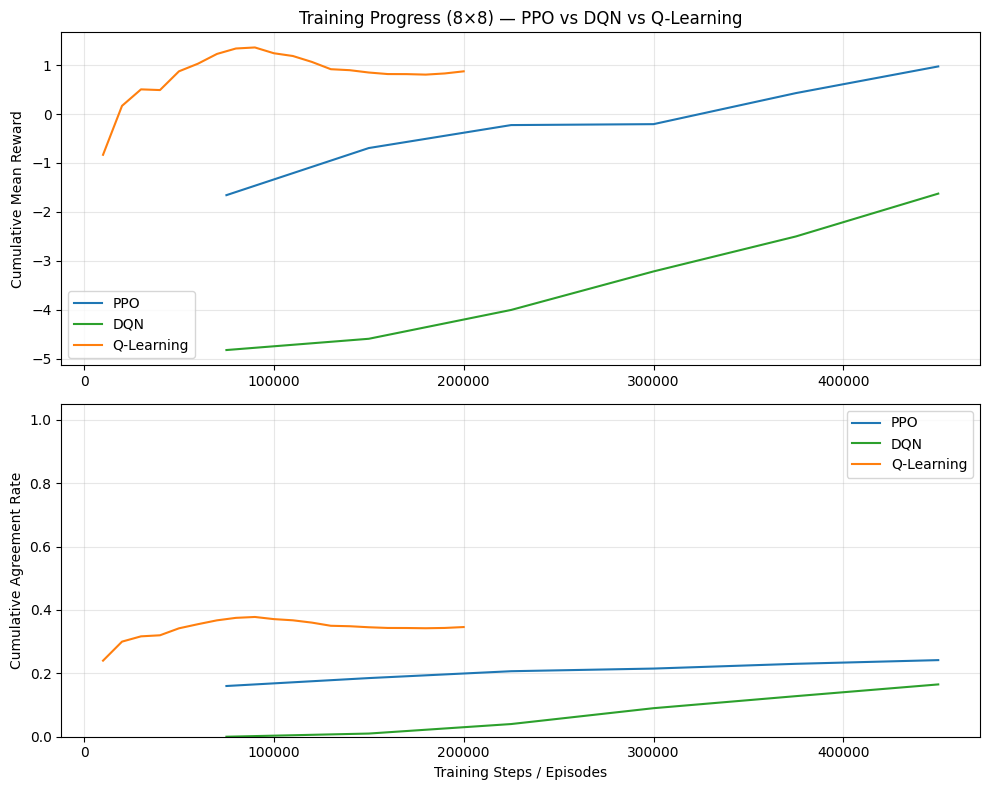

In [13]:
GRID = 8   # ← 8, 32, 64

algo_configs = [("ppo", "PPO", "tab:blue"), ("dqn", "DQN", "tab:green"), ("qlearning", "Q-Learning", "tab:orange")]
histories = {}
for algo, label, color in algo_configs:
    path = get_history_path(algo, GRID)
    if path.exists():
        with open(path, "rb") as f:
            histories[algo] = {"label": label, "color": color, **pickle.load(f)}
    else:
        print(f"  Skipping {label}: {path} not found")

if histories:
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)
    for algo, data in histories.items():
        steps = data["steps"]
        cum_reward = cumulative_avg(data["rewards"])
        cum_agreement = cumulative_avg(data["agreement"])
        axes[0].plot(steps, cum_reward, color=data["color"], linewidth=1.5, label=data["label"])
        axes[1].plot(steps, cum_agreement, color=data["color"], linewidth=1.5, label=data["label"])
    axes[0].set_ylabel("Cumulative Mean Reward")
    axes[0].set_title(f"Training Progress ({GRID}×{GRID}) — PPO vs DQN vs Q-Learning")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].set_ylabel("Cumulative Agreement Rate")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xlabel("Training Steps / Episodes")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plot_path = MODEL_DIR / f"training_plot_combined_{GRID}.png"
    plot_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Run PPO, DQN, Q-Learning first to generate training histories.")

### Σύγκριση όλων των μοντέλων (πίνακας)

In [14]:
N_EPISODES = 100  # ← μειώστε για ταχύτητα

results = []

for algo in ALGOS:
    for grid in GRID_SIZES:
        tag = str(grid)
        grid_size = (grid, grid)
        if not model_exists(algo, grid):
            results.append({"algo": algo, "grid": grid, "status": "not trained",
                            "success": None, "reward": None, "steps": None, "agreement": None})
            continue

        print(f"Evaluating {algo.upper()} {grid}×{grid}...", end=" ", flush=True)
        if algo == "ppo":
            from stable_baselines3 import PPO
            m = PPO.load(str(MODEL_DIR / "ppo" / f"nav_ppo_{tag}"))
            predict = lambda obs, _m=m: _m.predict(obs, deterministic=True)[0]
        elif algo == "dqn":
            from stable_baselines3 import DQN
            m = DQN.load(str(MODEL_DIR / "dqn" / f"nav_dqn_{tag}"))
            predict = lambda obs, _m=m: int(_m.predict(obs, deterministic=True)[0])
        else:
            with open(MODEL_DIR / "qlearning" / f"nav_qtable_{tag}.pkl", "rb") as f:
                qt = pickle.load(f)
            predict = lambda obs, _qt=qt: int(np.argmax(_qt.get(_discretize_nav(obs), np.zeros(_NAV_ACTIONS))))

        eval_max_steps = max(300, grid * grid // 2)
        stats = _eval_navigation(predict, n_episodes=N_EPISODES, grid_size=grid_size, max_steps=eval_max_steps)
        results.append({"algo": algo, "grid": grid, "status": "ok",
                        "reward": stats["mean_reward"],
                        "steps": stats["mean_steps"], "agreement": stats["agreement"]})
        print(f"agreement={stats['agreement']:.1%}")

# Pretty table
print(f"\n{'Algo':<12} {'Grid':>6} {'Reward':>9} {'Steps':>8} {'Agreement':>11}")
print("-" * 50)
for r in results:
    if r["status"] == "not trained":
        print(f"{r['algo']:<12} {r['grid']:>4}×{r['grid']:<4}  {'(not trained)':>30}")
    else:
        print(f"{r['algo']:<12} {r['grid']:>4}×{r['grid']:<4}  "
              f"{r['reward']:>9.4f}  {r['steps']:>7.1f}  {r['agreement']:>10.1%}")

Evaluating PPO 8×8... agreement=32.0%
Evaluating DQN 8×8... agreement=35.0%
Evaluating QLEARNING 8×8... agreement=40.0%

Algo           Grid    Reward    Steps   Agreement
--------------------------------------------------
ppo             8×8        3.7030    133.4       32.0%
dqn             8×8        2.2975    162.2       35.0%
qlearning       8×8        1.6971    173.9       40.0%
